In [1]:
import os, sys
import numpy as np
import pickle as pk
from random import randint
# from itertools import product, chain
# import scipy.interpolate as itp
from multiprocessing import Pool
sys.path.append('../scripts')
sys.path.append('../steps')
# sys.path.append('/home/nishant/lab/scripts')
from analysis import *
from peaks import *
from misc import *

# dataPath = "output/MFB/control/"

In [2]:
simType = 'control'
resultPath = os.path.join("../results/", simType)

In [3]:
siminfo = []
with open('newsims', 'r') as nf:
	for line in nf:
		siminfo.append([int(a) for a in line.split(' ')])
# print(siminfo, len(siminfo))


dirs = []
# for nVDCC, dVDCC, nAZ in product(nvdcc, dvdcc, naz):
for nVDCC, dVDCC, nAZ, RRP in siminfo:
    f = "nVDCC_" + str(nVDCC) + "_dVDCC_" + str(dVDCC) + "_nAZ_" + str(nAZ) + "_RRP_" + str(RRP) + "_ISI_20_nAP_10"
    dirs.append(f)

for i,d in enumerate(dirs):
    print(i, d)

0 nVDCC_10_dVDCC_120_nAZ_11_RRP_15_ISI_20_nAP_10
1 nVDCC_10_dVDCC_140_nAZ_31_RRP_5_ISI_20_nAP_10
2 nVDCC_10_dVDCC_140_nAZ_33_RRP_5_ISI_20_nAP_10
3 nVDCC_10_dVDCC_160_nAZ_7_RRP_45_ISI_20_nAP_10
4 nVDCC_10_dVDCC_160_nAZ_7_RRP_50_ISI_20_nAP_10
5 nVDCC_10_dVDCC_160_nAZ_7_RRP_55_ISI_20_nAP_10
6 nVDCC_10_dVDCC_160_nAZ_9_RRP_45_ISI_20_nAP_10
7 nVDCC_10_dVDCC_160_nAZ_9_RRP_50_ISI_20_nAP_10
8 nVDCC_10_dVDCC_180_nAZ_11_RRP_45_ISI_20_nAP_10
9 nVDCC_10_dVDCC_180_nAZ_11_RRP_50_ISI_20_nAP_10
10 nVDCC_10_dVDCC_180_nAZ_31_RRP_10_ISI_20_nAP_10
11 nVDCC_10_dVDCC_180_nAZ_33_RRP_10_ISI_20_nAP_10
12 nVDCC_10_dVDCC_180_nAZ_7_RRP_60_ISI_20_nAP_10
13 nVDCC_10_dVDCC_180_nAZ_9_RRP_45_ISI_20_nAP_10
14 nVDCC_10_dVDCC_180_nAZ_9_RRP_55_ISI_20_nAP_10
15 nVDCC_10_dVDCC_180_nAZ_9_RRP_60_ISI_20_nAP_10
16 nVDCC_10_dVDCC_200_nAZ_11_RRP_45_ISI_20_nAP_10
17 nVDCC_10_dVDCC_200_nAZ_11_RRP_50_ISI_20_nAP_10
18 nVDCC_10_dVDCC_200_nAZ_11_RRP_55_ISI_20_nAP_10
19 nVDCC_10_dVDCC_200_nAZ_11_RRP_60_ISI_20_nAP_10
20 nVDCC_10_dVDCC_200

In [5]:
dd = []
for i in [15,14,13,12,11,9,8,7,6,5,4,3,2,1]:
    dd = dd + [d for d in dirs if f'nVDCC_{i}_' in d]


dd = [d for d in dd if 'nAZ_31' not in d]
dd = [d for d in dd if 'nAZ_33' not in d]
dd = [d for d in dd if 'nAZ_35' not in d]

dd = [d for d in dirs if 'nAZ_31' in d][13:] + [d for d in dirs if 'nAZ_33' in d] + [d for d in dirs if 'nAZ_35' in d]
tempdirs = dd 

for i,d in enumerate(tempdirs):
    print(i, d)

0 nVDCC_3_dVDCC_100_nAZ_31_RRP_55_ISI_20_nAP_10
1 nVDCC_3_dVDCC_100_nAZ_31_RRP_60_ISI_20_nAP_10
2 nVDCC_3_dVDCC_60_nAZ_31_RRP_5_ISI_20_nAP_10
3 nVDCC_3_dVDCC_80_nAZ_31_RRP_30_ISI_20_nAP_10
4 nVDCC_3_dVDCC_80_nAZ_31_RRP_35_ISI_20_nAP_10
5 nVDCC_3_dVDCC_80_nAZ_31_RRP_40_ISI_20_nAP_10
6 nVDCC_4_dVDCC_100_nAZ_31_RRP_25_ISI_20_nAP_10
7 nVDCC_4_dVDCC_100_nAZ_31_RRP_30_ISI_20_nAP_10
8 nVDCC_4_dVDCC_100_nAZ_31_RRP_35_ISI_20_nAP_10
9 nVDCC_4_dVDCC_120_nAZ_31_RRP_40_ISI_20_nAP_10
10 nVDCC_4_dVDCC_120_nAZ_31_RRP_45_ISI_20_nAP_10
11 nVDCC_4_dVDCC_120_nAZ_31_RRP_50_ISI_20_nAP_10
12 nVDCC_4_dVDCC_140_nAZ_31_RRP_60_ISI_20_nAP_10
13 nVDCC_4_dVDCC_80_nAZ_31_RRP_15_ISI_20_nAP_10
14 nVDCC_4_dVDCC_80_nAZ_31_RRP_20_ISI_20_nAP_10
15 nVDCC_5_dVDCC_100_nAZ_31_RRP_15_ISI_20_nAP_10
16 nVDCC_5_dVDCC_100_nAZ_31_RRP_20_ISI_20_nAP_10
17 nVDCC_5_dVDCC_120_nAZ_31_RRP_25_ISI_20_nAP_10
18 nVDCC_5_dVDCC_120_nAZ_31_RRP_30_ISI_20_nAP_10
19 nVDCC_5_dVDCC_140_nAZ_31_RRP_35_ISI_20_nAP_10
20 nVDCC_5_dVDCC_140_nAZ_31_RRP_40_IS

## AZ simulation in STEPS

In [10]:
from MFB_model import *
mdl, sim, r = get_MFB_model()

In [13]:
def runAZTrials(CaData, RRPs):
    vesData = []
    resAZs = []
    # print(CaData[0], CaData[1], RRPs)
    for RRP in RRPs:
        # resCa, resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
        resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
        vesRelTot = np.sum(vesRel, axis=1)
        pks = detect_peaks(vesRelTot, edge='rising', show=False)
        vesData.append(list(CaData[0,pks]))
        resAZs.append(resAZ)
    
    return [vesData, resAZs]

def getVesRel(dir, RRPs, resultPath, fname='CaConc.dat', trials=2000):
    nAZ = int(getSimInfo(dir, 'nAZ'))
    rrps = len(RRPs)
    
    CaFile = os.path.join(resultPath, dir, fname)
    CaData = np.genfromtxt(CaFile, unpack=True) # in uM
    
    p = Pool()
    vesRelTimes = []
    for iCa in tq(range(1,nAZ+1), desc=dir):
    # for iCa in range(1,nAZ+1):
        
        info = product([CaData[(0,iCa),:]], [RRPs]*trials)
        # print(list(info)[0])
        vesRelTime = np.array(p.starmap(runAZTrials, info), dtype=object)
        # vesRelTime = runAZTrials(CaData[(0,iCa),:], RRPs)

        # print(vesRelTime[:,0])
        AZstates = vesRelTime[:,1]
        vesRelTime = vesRelTime[:,0]
        vesRelTime = [[vesRelTime[i][j] for i in range(trials)] for j in range(rrps)]
        vesRelTimes.append(vesRelTime)
        #print(vesRelTime[:,1])

        AZstates = np.mean(AZstates, axis=0)

        #print(AZstates[0])
        #print(np.vstack((CaData[0,],AZstates[0])))
    
        for i,rrp in enumerate(RRPs):
            fAZ = os.path.join(resultPath, dir, f'AZ_{iCa}_RRP_{rrp}.dat')
            AZdata = np.hstack((np.array([CaData[0]]).T, AZstates[i]))
            np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.3f']*18, delimiter="\t")

    p.close()
    p.join()
    
    vesRelTimes = [[list(chain(*[vesRelTimes[i][j][k] for i in range(nAZ)])) for k in range(trials)] for j in range(rrps)]
    vesData = {}
    for RRP,v in zip(RRPs, vesRelTimes):
        vesData.update({str(RRP): v})
    
    return vesData

# dir = tempdirs[1] 
# rrp = int(getSimInfo(dir, 'RRP'))
# vesData = getVesRel(dir, RRPs=[rrp], resultPath=resultPath, trials=35)

In [14]:
for dir in tq(tempdirs):
    try:
        rrp = int(getSimInfo(dir, 'RRP'))
        vesData = getVesRel(dir, RRPs=[rrp], resultPath=resultPath, trials=2000)
        with open(os.path.join(resultPath, dir, 'vesData.dat'),"wb") as outfile:
            pk.dump(vesData, outfile)
    except:
        print(f'Error in {dir}')

 61%|██████    | 401/655 [234:39:24<163:39:25, 2319.55s/it]

Error in nVDCC_3_dVDCC_100_nAZ_31_RRP_55_ISI_20_nAP_10


---
#### Errors in getVesRel
- nVDCC_6_dVDCC_100_nAZ_7_RRP_45_ISI_20_nAP_10
- nVDCC_6_dVDCC_100_nAZ_7_RRP_55_ISI_20_nAP_10
- nVDCC_6_dVDCC_140_nAZ_15_RRP_60_ISI_20_nAP_10
- nVDCC_5_dVDCC_140_nAZ_27_RRP_45_ISI_20_nAP_10
- nVDCC_5_dVDCC_160_nAZ_29_RRP_60_ISI_20_nAP_10



## Get Vesicle Release Statistics

In [4]:
info = [[d, resultPath] for d in tempdirs]

p = Pool(35)
p.starmap(relStat, info)


# for d in tq(tempdirs[:100]):
#     # relStat(d, resultPath, resample=10)
#     try:
#         relStat(d, resultPath)
#     except:
#         print(f'Error in {d}')

Resampling [6, 200, 35, 50, 20]: 100%|██████████| 1000/1000 [1:42:50<00:00,  6.17s/it]


[array([[0.298156  , 0.00950451, 0.346265  , 0.01214378, 1.        ,
         0.        ],
        [0.4673175 , 0.01138969, 0.643371  , 0.01777418, 1.56894924,
         0.0628317 ],
        [0.621101  , 0.01095458, 0.9859475 , 0.02237561, 2.08529583,
         0.07707112],
        [0.729423  , 0.00961205, 1.2850485 , 0.02429922, 2.44895186,
         0.08512523],
        [0.7833965 , 0.00890733, 1.49379   , 0.02571438, 2.63017359,
         0.08995898],
        [0.811459  , 0.00905231, 1.65763   , 0.02885508, 2.72436751,
         0.09236757],
        [0.849168  , 0.00794102, 1.8342255 , 0.02958182, 2.85101929,
         0.0964886 ],
        [0.8854715 , 0.00679481, 2.0810735 , 0.03067303, 2.97286089,
         0.09801302],
        [0.9014465 , 0.00663697, 2.1887395 , 0.03073244, 3.02652143,
         0.10030542],
        [0.9066305 , 0.00644502, 2.273286  , 0.03298126, 3.04392269,
         0.10065825]]),
 array([[0.2114405 , 0.00895079, 0.2370575 , 0.01058147, 1.        ,
         0.        

## Plotting Data

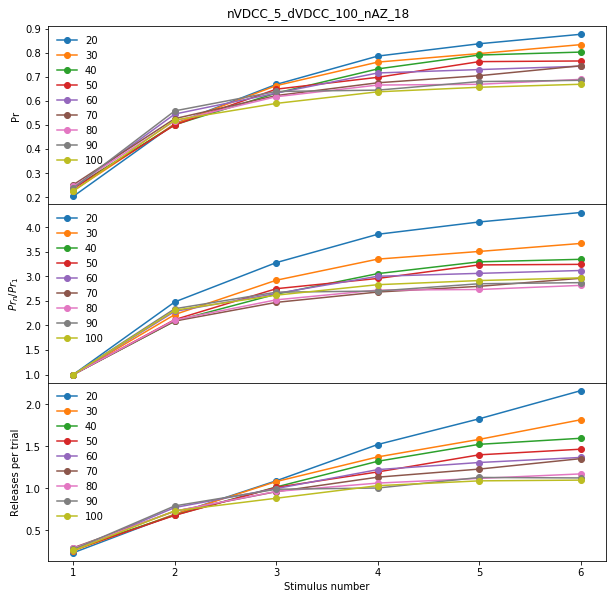

In [ ]:
nFig = 3
figure, ax = plt.subplots(nFig, figsize=(10, 3*nFig), sharex=True)
#figure.tight_layout()
figure.subplots_adjust(hspace=0.0, top=.95)

for d in tempdirs[1:].tolist()+tempdirs[:1].tolist():
    fname = os.path.join(resultPath, d, 'result_RRP_35.dat')
    relData = np.genfromtxt(fname, unpack=True)

    ax[0].plot(range(1,len(relData[0])+1), relData[0], 'o-', label=getSimInfo(d, 'ISI'))
    ax[0].set_ylabel('Pr')
    ax[0].legend(frameon=False)
    
    ax[1].plot(range(1,len(relData[0])+1), relData[0]/relData[0][0], 'o-', label=getSimInfo(d, 'ISI'))
    ax[1].set_ylabel('$Pr_n/Pr_1$')
    ax[1].legend(frameon=False)
    
    ax[2].plot(range(1,len(relData[0])+1), relData[2], 'o-', label=getSimInfo(d, 'ISI'))
    ax[2].set_ylabel('Releases per trial')
    ax[2].set_xlabel('Stimulus number')
    ax[2].legend(frameon=False)

figure.suptitle("nVDCC_5_dVDCC_100_nAZ_18")
figure.savefig('nVDCC_5_dVDCC_100_nAZ_18.eps', fmt='eps', dpi=300, transparent=True)

## Testing a single trial with STEPS

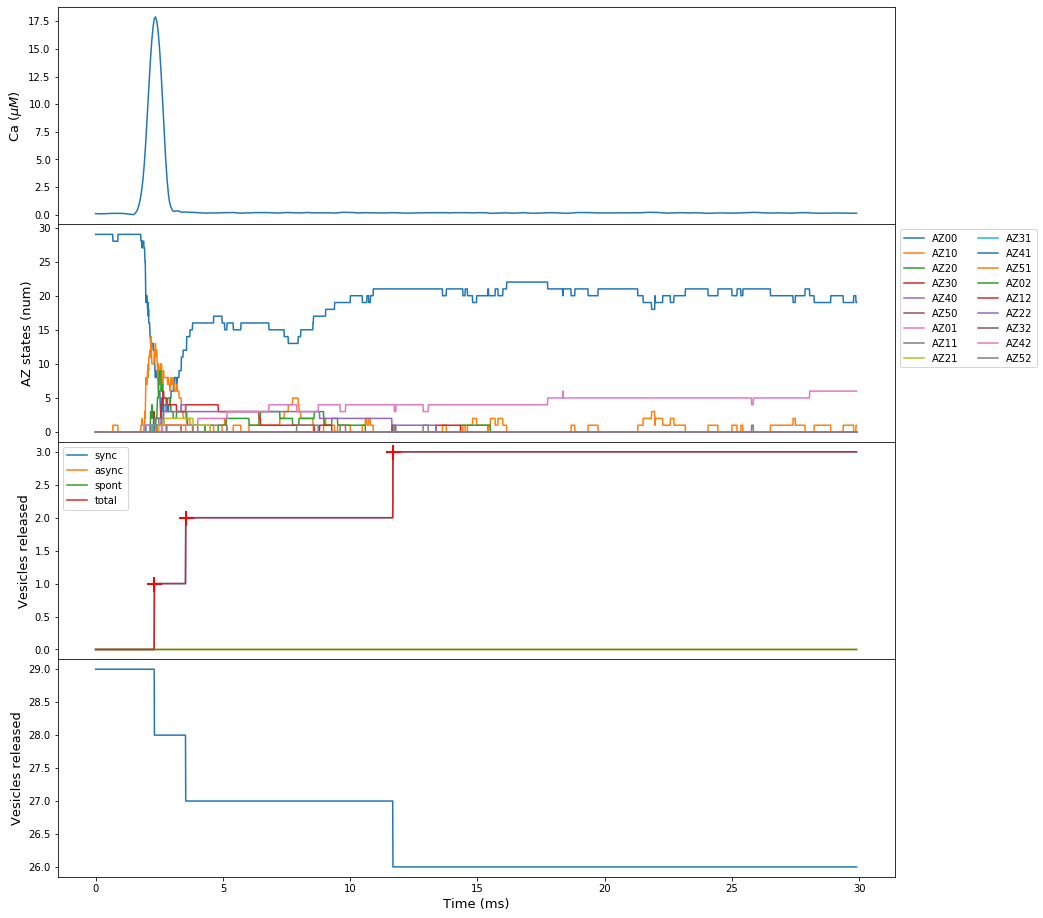

In [ ]:
CaFile = resultPath + 'nVDCC_9_dVDCC_60_nAZ_29/CaConc.dat'
CaData = np.genfromtxt(CaFile, unpack=True)

T = np.arange(CaData[0][0], CaData[0][-1], 1e-5)
CaInterp = itp.interp1d(CaData[0], CaData[1])
CaInterpData = CaInterp(T)

resAZ, vesRel = simAZtest(T, CaInterpData, sim, r)

nFig = 4
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
figure.subplots_adjust(hspace=0.0)
labelfontsize = 13

T=T*1e3
ax[0].plot(T, CaInterpData, label='Ca')
ax[0].set_ylabel(r'Ca ($\mu M$)', fontsize=labelfontsize)

for mol in azMolName[:18]:
    i = azMolName.index(mol)
    ax[1].plot(T, resAZ[:,i], label=mol)
ax[1].set_ylabel('AZ states (num)', fontsize=labelfontsize)
ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)

vesRelSync  = np.sum(vesRel[:,:3], axis=1)
vesRelAsync = np.sum(vesRel[:,3:-1], axis=1)
vesRelSpont = vesRel[:,-1]
vesRelTot   = np.sum(vesRel, axis=1)

ax[2].plot(T, vesRelSync, label='sync')
ax[2].plot(T, vesRelAsync, label='async')
ax[2].plot(T, vesRelSpont, label='spont')
ax[2].plot(T, vesRelTot, label='total')
    
ax[2].set_ylabel('Vesicles released', fontsize=labelfontsize)

ax[2].legend()

peaks = detect_peaks(vesRelTot, edge='rising', show=False)
ax[2].plot(T[peaks], vesRelTot[peaks], '+', mfc=None, mec='r', mew=2, ms=15)
#print(T[peaks])

rrp = np.sum(resAZ, axis=1)
ax[3].plot(T, rrp, label='total')
ax[3].set_ylabel('Vesicles released', fontsize=labelfontsize)
ax[3].set_xlabel('Time (ms)', fontsize=labelfontsize)

plt.show()